# 05 模型可靠性：split、泄漏与适用域

这一节讨论一个更科学的问题：模型在什么情况下可信？

应用场景：当模型要给新分子排序、筛选候选或建议实验时，单个 random-split 分数不够。
我们需要知道测试分子是否只是训练集近邻，或者是否真的代表新的化学结构空间。

## 直觉解释

如果测试集里有许多训练集近邻，模型看起来会很好。scaffold split 更像“考新题”，random split 更像“同一题型换数字”。

本节使用 Murcko scaffold 近似“分子核心骨架”。Bemis 和 Murcko 提出的 molecular framework 思路
常用于把分子按核心骨架分组；在机器学习评估中，scaffold split 常作为比 random split 更严格的结构外推检查。

## 数学/化学定义

data leakage 指测试信息进入训练流程。适用域指模型比较有证据支持的输入范围。

一种简单适用域指标：

```text
nearest_train_similarity(test molecule) = max Tanimoto(test, each train molecule)
```

相似度越低，模型越可能是在分布外预测。

## 准备 random split 和 scaffold split

这一格建立同一份 ESOL 特征，然后生成两种划分：

- random split：随机抽测试集，通常测试插值能力。
- scaffold split：按 scaffold 分组抽测试集，测试集核心骨架更可能没在训练集中出现。

In [1]:
from pathlib import Path

START = Path.cwd().resolve()
for candidate in [START, *START.parents]:
    if (candidate / "data").exists() and (candidate / "notebooks").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Cannot find the materials root. Start Jupyter from the materials directory "
        "or from one of its subdirectories."
    )

DATA = ROOT / "data"
RAW = DATA / "raw"
EXAMPLES = DATA / "examples"
RANDOM_STATE = 42

# print("materials root:", ROOT)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, DataStructs
from rdkit.Chem import Crippen, Descriptors, Draw, Lipinski, rdFingerprintGenerator, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

sns.set_theme(style="whitegrid", context="notebook")


def mol_from_smiles(smiles):
    if pd.isna(smiles):
        return None
    return Chem.MolFromSmiles(str(smiles).strip())


def canonical_smiles(smiles):
    mol = mol_from_smiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol)


def scaffold_smiles(mol):
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)


def descriptor_record(smiles):
    mol = mol_from_smiles(smiles)
    if mol is None:
        return None
    return {
        "MolWt": Descriptors.MolWt(mol),
        "MolLogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
        "RingCount": rdMolDescriptors.CalcNumRings(mol),
        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol),
        "canonical_smiles": canonical_smiles(smiles),
        "scaffold": scaffold_smiles(mol),
    }


def build_esol_features():
    raw = pd.read_csv(RAW / "esol.csv")
    rows = []
    for row_id, row in raw.reset_index(drop=True).iterrows():
        desc = descriptor_record(row["smiles"])
        if desc is None:
            continue
        desc.update(
            {
                "row_id": row_id,
                "smiles": str(row["smiles"]).strip(),
                "logS": float(row["log solubility (mol/L)"]),
            }
        )
        rows.append(desc)
    return pd.DataFrame(rows)


def fingerprint_array(smiles, n_bits=1024):
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
    matrix = np.zeros((len(smiles), n_bits), dtype=np.int8)
    for idx, smi in enumerate(smiles):
        fp = generator.GetFingerprint(mol_from_smiles(smi))
        DataStructs.ConvertToNumpyArray(fp, matrix[idx])
    return matrix


DESCRIPTOR_COLUMNS = [
    "MolWt",
    "MolLogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "RingCount",
    "AromaticRings",
    "FractionCSP3",
    "HeavyAtomCount",
]

In [3]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupShuffleSplit, train_test_split

esol = build_esol_features()
X = esol[DESCRIPTOR_COLUMNS].to_numpy(dtype=float)
y = esol["logS"].to_numpy(dtype=float)
indices = np.arange(len(esol))

# random split 不关心化学骨架，只随机抽样。
random_train, random_test = train_test_split(indices, test_size=0.2, random_state=RANDOM_STATE)

# GroupShuffleSplit 保证同一个 scaffold group 不会同时进入 train/test。
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
scaffold_train, scaffold_test = next(splitter.split(X, y, groups=esol["scaffold"]))

## 代码

用同一个模型比较 random split 和 scaffold split。差异越大，越说明评价依赖划分方式。

In [4]:
def fit_and_score(train_idx, test_idx):
    # 固定模型，只改变 split；这样差异主要来自评价设置，而不是模型选择。
    model = RandomForestRegressor(n_estimators=60, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X[train_idx], y[train_idx])
    pred_train = model.predict(X[train_idx])
    pred_test = model.predict(X[test_idx])
    return {
        "train_RMSE": mean_squared_error(y[train_idx], pred_train) ** 0.5,
        "test_RMSE": mean_squared_error(y[test_idx], pred_test) ** 0.5,
        "pred_test": pred_test,
    }

scores = {
    "random split": fit_and_score(random_train, random_test),
    "scaffold split": fit_and_score(scaffold_train, scaffold_test),
}

pd.DataFrame(
    [
        {"split": name, "train_RMSE": value["train_RMSE"], "test_RMSE": value["test_RMSE"]}
        for name, value in scores.items()
    ]
).round(3)

,split,train_RMSE,test_RMSE
0,random split,0.272,0.796
1,scaffold split,0.283,0.892


## 用最近训练邻居估计适用域

对每个测试分子，计算它和所有训练分子的 Morgan fingerprint Tanimoto similarity，
取最大值作为 `nearest_train_similarity`。这不是严格不确定性，但能提供一个直观的适用域 proxy。

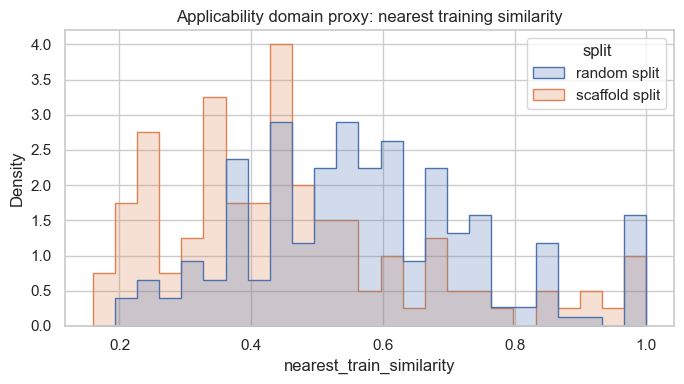

In [ ]:
def nearest_train_similarity(train_idx, test_idx):
    all_fp = []
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
    for smi in esol["smiles"]:
        all_fp.append(generator.GetFingerprint(mol_from_smiles(smi)))
    out = []
    train_fps = [all_fp[i] for i in train_idx]
    for idx in test_idx:
        # BulkTanimotoSimilarity 一次计算当前测试分子和所有训练分子的相似度。
        # 在 C++ 层循环完成，避免 Python interpreter loop，减少对象封装/解封装次数，估计有5～50倍速率提升。
        sims = DataStructs.BulkTanimotoSimilarity(all_fp[idx], train_fps)
        out.append(max(sims))
    return np.array(out)

random_nn = nearest_train_similarity(random_train, random_test)
scaffold_nn = nearest_train_similarity(scaffold_train, scaffold_test)

sim_df = pd.DataFrame(
    {
        "nearest_train_similarity": np.r_[random_nn, scaffold_nn],
        "split": ["random split"] * len(random_nn) + ["scaffold split"] * len(scaffold_nn),
    }
)

plt.figure(figsize=(7, 4))
sns.histplot(data=sim_df, x="nearest_train_similarity", hue="split", bins=25, element="step", stat="density", common_norm=False)
plt.title("Applicability domain proxy: nearest training similarity")
plt.tight_layout()

## 找低相似度和高错误样例

这一格把 scaffold split 的预测误差和最近邻相似度放在同一张表里。
讨论时可以问：这些分子是模型真的不会，还是训练集里缺少相似化学环境？

In [6]:
reliability_df = pd.DataFrame(
    {
        "true_logS": y[scaffold_test],
        "pred_logS": scores["scaffold split"]["pred_test"],
        "nearest_train_similarity": scaffold_nn,
        "smiles": esol.iloc[scaffold_test]["smiles"].to_numpy(),
    }
)
reliability_df["abs_error"] = (reliability_df["true_logS"] - reliability_df["pred_logS"]).abs()
reliability_df.sort_values(["nearest_train_similarity", "abs_error"], ascending=[True, False]).head(8).round(3)

,true_logS,pred_logS,nearest_train_similarity,smiles,abs_error
47,-1.989,-2.483,0.159,Nc1cc(nc(N)n1=O)N2CCCCC2,0.494
69,-2.676,-1.602,0.192,CSc1nc(nc(n1)N(C)C)N(C)C,1.074
32,-1.877,-2.190,0.192,CN1CC(O)N(C1=O)c2nnc(s2)C(C)(C)C,0.313
96,-4.430,-2.278,0.200,CC(C)Nc1nc(Cl)nc(NC(C)C)n1,2.152
91,-3.150,-2.588,0.205,CCNc1nc(Cl)nc(NC(C)(C)C#N)n1,0.562
99,-4.100,-2.667,0.208,CSc1nc(NC(C)C)nc(NC(C)C)n1,1.433
16,-3.785,-2.232,0.212,CCN(CC)c1nc(Cl)nc(NC(C)C)n1,1.553
59,-3.685,-1.608,0.217,Cc3cc2nc1c(=O)[nH]c(=O)nc1n(CC(O)C(O)C(O)CO)c2...,2.077


## 可视化风险关系

横轴越低，表示测试分子离训练集越远；纵轴越高，表示预测误差越大。
如果看到低相似度区域错误更大，就应该把模型输出当作假设，而不是确定结论。

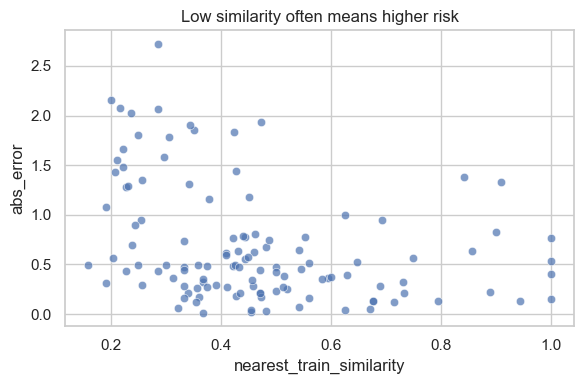

In [7]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=reliability_df, x="nearest_train_similarity", y="abs_error", alpha=0.7)
plt.title("Low similarity often means higher risk")
plt.tight_layout()

## 观察问题

1. random split 和 scaffold split 的 test RMSE 哪个更高？
2. scaffold split 的测试分子和训练集最近邻相似度是否更低？
3. 如果一个分子 nearest similarity 很低，你会如何使用模型预测？

### Hints

1. 通常 scaffold split 更高，但要看这次随机种子和数据分布；关键是解释为什么。
2. 如果 scaffold split 成功制造了结构外推，最近邻相似度分布应该整体更低。
3. 低相似度预测更适合作为“需要进一步验证的假设”。可以要求实验确认、查找外部相似数据，或让模型 abstain。

## 小结

模型可靠性不是只看一个分数。要同时看 split、重复、近邻相似性、错误样例和化学解释。对于低相似度样本，预测应被视为假设，而不是结论。